# Image Compression with the SVD

Every channel of an image is just a matrix. The singular value decomposition writes
that matrix as a weighted sum of rank-one layers,

$$A \;=\; U\Sigma V^{\mathsf T} \;=\; \sum_{i=1}^{r}\sigma_i\, u_i v_i^{\mathsf T},
\qquad \sigma_1 \ge \sigma_2 \ge \dots \ge 0 .$$

Cutting the sum off after $k$ terms gives $A_k$, and the **Eckart-Young theorem**
says no other rank-$k$ matrix comes closer to $A$ in Frobenius norm. So the leading
singular values *are* the strongest features of the picture.

Storage falls from $mn$ numbers per channel to $k(m+n+1)$: the first $k$ columns of
$U$, the first $k$ singular values, and the first $k$ rows of $V^{\mathsf T}$.

This notebook walks through the whole pipeline: decompose, inspect the spectrum,
truncate, measure, and rebuild the picture.

## 0. Requirements

Three libraries do all the work: `numpy` for the decomposition, `pillow` to read
and write images, `matplotlib` to draw. Run the cell below once.

`%pip` installs into whichever kernel is executing this notebook, so it lands in
the active conda environment rather than in `base` or in some other Python on the
machine. That is what makes it safe here. The conda equivalent, if you would
rather keep the environment managed by conda alone, is

```
conda install -y numpy pillow matplotlib
```

Either way you also need `ipykernel` in that environment for the notebook to have
a kernel at all, plus `jupyterlab` if you open notebooks in a browser instead of
an IDE.

In [1]:
# Safe to re-run: pip skips anything already satisfied.
%pip install -q numpy pillow matplotlib ipykernel

import sys
import numpy, PIL, matplotlib

print("kernel :", sys.executable)
print("numpy  :", numpy.__version__)
print("pillow :", PIL.__version__)
print("mpl    :", matplotlib.__version__)

Note: you may need to restart the kernel to use updated packages.
kernel : /opt/anaconda3/envs/shared_env/bin/python
numpy  : 2.5.3
pillow : 12.3.0
mpl    : 3.11.2


## 1. Setup

In [ ]:
import os

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["image.interpolation"] = "nearest"

IMAGE_PATH = "images/sample_photo.jpg"   # swap in any image of your own
OUTDIR = "output_notebook"
os.makedirs(OUTDIR, exist_ok=True)

In [16]:


# Load the image using Pillow
img = Image.open(IMAGE_PATH)

# Convert the image to a NumPy array
img_array = np.array(img)

print(img_array.shape)  # Outputs: (Height, Width, Channels)


(288, 512, 3)


## 2. Load the image

Pixels are scaled to $[0, 1]$ so the error metrics later have a clean reference
range. A grayscale image is given a trailing axis of length one, which lets the
same code path handle both cases.

shape      : 288 x 512, 3 channel(s)
max rank   : 288
raw numbers: 442,368


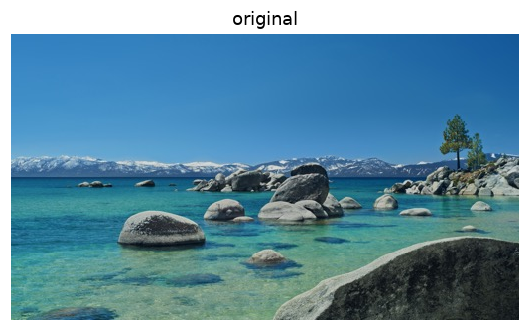

In [3]:
def load_image(path, gray=False):
    a = np.asarray(Image.open(path).convert("L" if gray else "RGB"), dtype=np.float64) / 255.0
    return a[:, :, None] if a.ndim == 2 else a


A = load_image(IMAGE_PATH)
m, n, ch = A.shape
rmax = min(m, n)

print(f"shape      : {m} x {n}, {ch} channel(s)")
print(f"max rank   : {rmax}")
print(f"raw numbers: {m * n * ch:,}")

plt.figure(figsize=(6, 6 * m / n))
plt.imshow(A if ch == 3 else A[:, :, 0], cmap=None if ch == 3 else "gray")
plt.title("original")
plt.axis("off")
plt.show()

## 3. Decompose every channel

`full_matrices=False` gives the thin SVD, which is all a rank-$k$ truncation ever
needs: $U$ is $m \times r$, $s$ has length $r$, and $V^{\mathsf T}$ is $r \times n$
with $r=\min(m,n)$.

In [4]:
def svd_channels(a):
    return [np.linalg.svd(a[:, :, c], full_matrices=False) for c in range(a.shape[2])]


parts = svd_channels(A)
U0, s0, Vt0 = parts[0]
print(f"U  {U0.shape}   s  {s0.shape}   Vt  {Vt0.shape}")
print(f"largest sigma : {s0[0]:.2f}")
print(f"smallest sigma: {s0[-1]:.2e}")

U  (288, 288)   s  (288,)   Vt  (288, 512)
largest sigma : 104.66
smallest sigma: 5.87e-03


## 4. Where does the energy live?

The energy of layer $i$ is $\sigma_i^2$, so the fraction captured by the first $k$
layers is $\sum_{i\le k}\sigma_i^2 \big/ \sum_i \sigma_i^2$. A spectrum that falls
off a cliff is exactly what makes compression work.

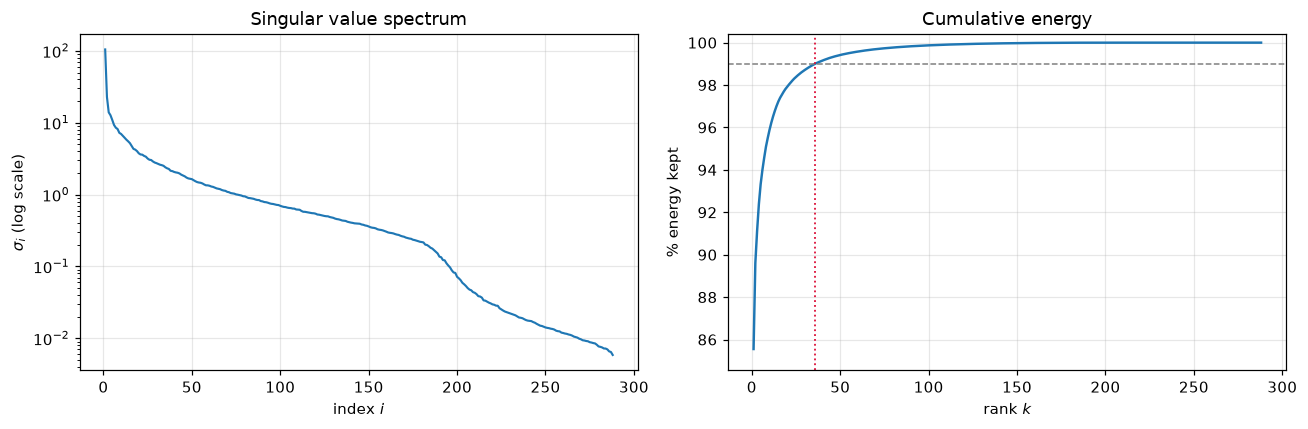

99% of the energy sits in the first 36 of 288 singular values


In [5]:
energy = np.cumsum(s0 ** 2) / np.sum(s0 ** 2)
k99 = int(np.searchsorted(energy, 0.99) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(np.arange(1, len(s0) + 1), s0, lw=1.4)
ax[0].set(title="Singular value spectrum", xlabel="index $i$", ylabel="$\\sigma_i$ (log scale)")
ax[1].plot(np.arange(1, len(energy) + 1), energy * 100, lw=1.6)
ax[1].axhline(99, ls="--", c="gray", lw=1)
ax[1].axvline(k99, ls=":", c="crimson", lw=1.2)
ax[1].set(title="Cumulative energy", xlabel="rank $k$", ylabel="% energy kept",
          ylim=(min(90, energy[0] * 100 - 1), 100.4))
for a_ in ax:
    a_.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"99% of the energy sits in the first {k99} of {rmax} singular values")

## 5. Rebuild from the top $k$ features

$A_k = U_{:,:k}\,\operatorname{diag}(s_{:k})\,V^{\mathsf T}_{:k,:}$, done channel by
channel. Clipping is only there because floating-point round-off can push a pixel a
hair outside $[0, 1]$.

In [6]:
def reconstruct(parts, k, shape):
    out = np.empty(shape)
    for c, (u, s, vt) in enumerate(parts):
        out[:, :, c] = (u[:, :k] * s[:k]) @ vt[:k, :]
    return np.clip(out, 0.0, 1.0)


RANKS = [1, 5, 10, 20, 50, 100]
RANKS = [k for k in RANKS if 1 <= k <= rmax]
recons = {k: reconstruct(parts, k, A.shape) for k in RANKS}
print("reconstructed ranks:", RANKS)

reconstructed ranks: [1, 5, 10, 20, 50, 100]


### Visualise the reconstructions against the original

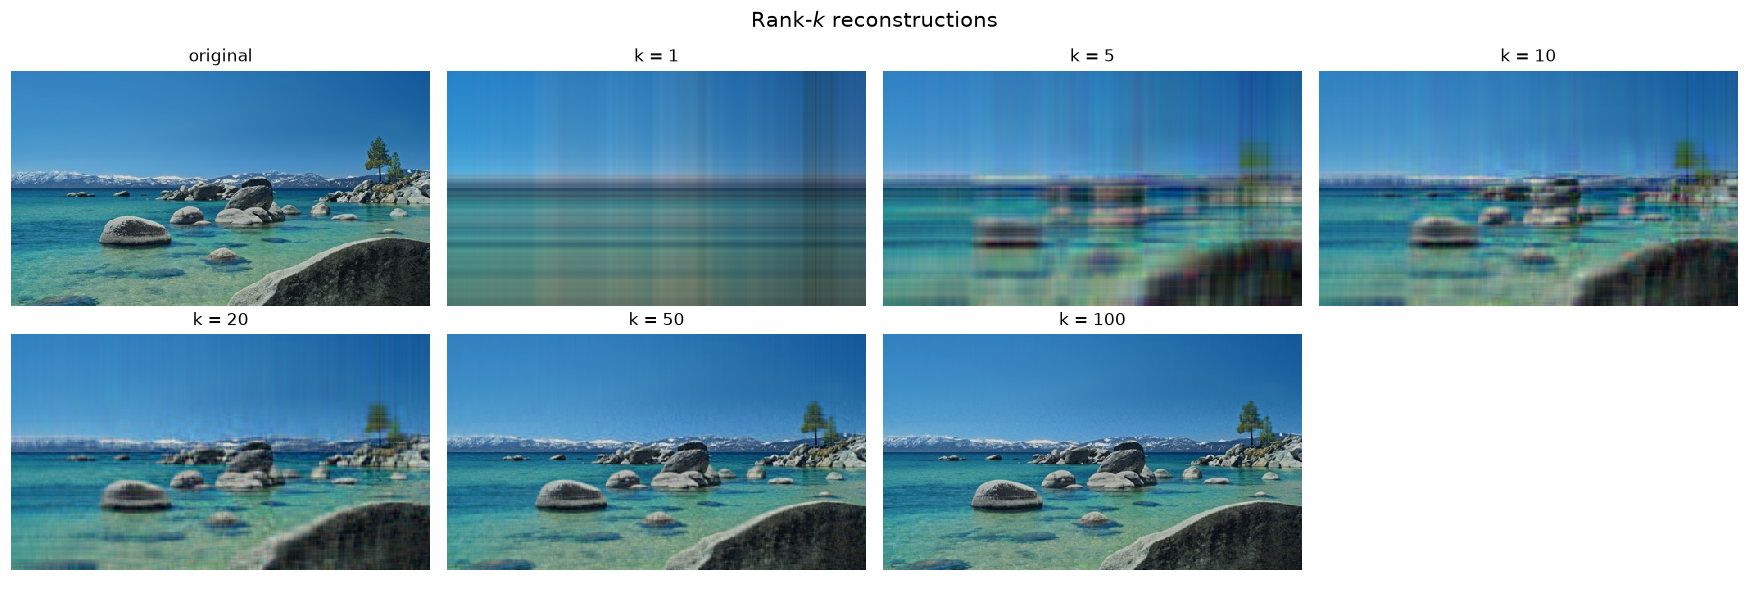

In [7]:
tiles = [("original", A)] + [(f"k = {k}", recons[k]) for k in RANKS]
cols = min(4, len(tiles))
rows = -(-len(tiles) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows * m / n + 1))
flat = np.atleast_1d(axes).ravel()
for ax, (title, img) in zip(flat, tiles):
    ax.imshow(img if ch == 3 else img[:, :, 0], cmap=None if ch == 3 else "gray")
    ax.set_title(title, fontsize=11)
    ax.axis("off")
for ax in flat[len(tiles):]:
    ax.axis("off")
fig.suptitle("Rank-$k$ reconstructions", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "comparison_grid.png"), bbox_inches="tight")
plt.show()

## 6. How much did we actually save?

Two numbers matter. **Compression ratio** compares $mn$ against $k(m+n+1)$ per
channel, and **PSNR** measures how faithful the reconstruction is:

$$\mathrm{PSNR} = 10\log_{10}\!\frac{1}{\mathrm{MSE}} \ \text{dB}
\quad\text{(pixels in } [0,1]).$$

Above roughly 30 dB the difference is hard to see at normal viewing size.

In [8]:
def psnr(orig, approx):
    mse = np.mean((orig - approx) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(1.0 / mse)


full = m * n * ch
header = f"{'k':>5} {'stored':>12} {'ratio':>8} {'energy':>9} {'PSNR dB':>9}"
print(header)
print("-" * len(header))

stats = []
for k in RANKS:
    kept = k * (m + n + 1) * ch
    q = psnr(A, recons[k])
    stats.append((k, kept, full / kept, energy[k - 1], q))
    print(f"{k:>5} {kept:>12,} {full / kept:>7.1f}x {energy[k - 1]:>8.1%} {q:>9.2f}")

breakeven = full / ((m + n + 1) * ch)
print(f"\ncompression pays off for any k below {breakeven:.0f}")

    k       stored    ratio    energy   PSNR dB
-----------------------------------------------
    1        2,403   184.1x    85.6%     19.03
    5       12,015    36.8x    93.3%     23.01
   10       24,030    18.4x    95.9%     25.04
   20       48,060     9.2x    97.9%     27.79
   50      120,150     3.7x    99.4%     32.98
  100      240,300     1.8x    99.9%     39.43

compression pays off for any k below 184


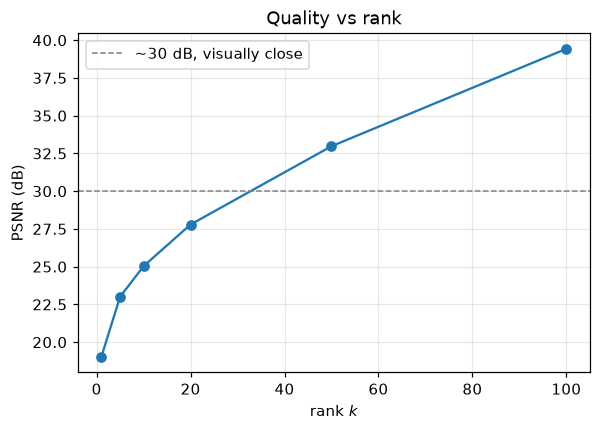

In [9]:
plt.figure(figsize=(6, 4))
plt.plot([s[0] for s in stats], [s[4] for s in stats], "o-")
plt.axhline(30, ls="--", c="gray", lw=1, label="~30 dB, visually close")
plt.xlabel("rank $k$")
plt.ylabel("PSNR (dB)")
plt.title("Quality vs rank")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 7. Pick a rank and look at the result

The rank that holds 99% of the energy is a reasonable automatic choice. Here it sits
beside the original, with the error image showing where the discarded layers were
carrying detail: edges and fine texture, never the flat regions.

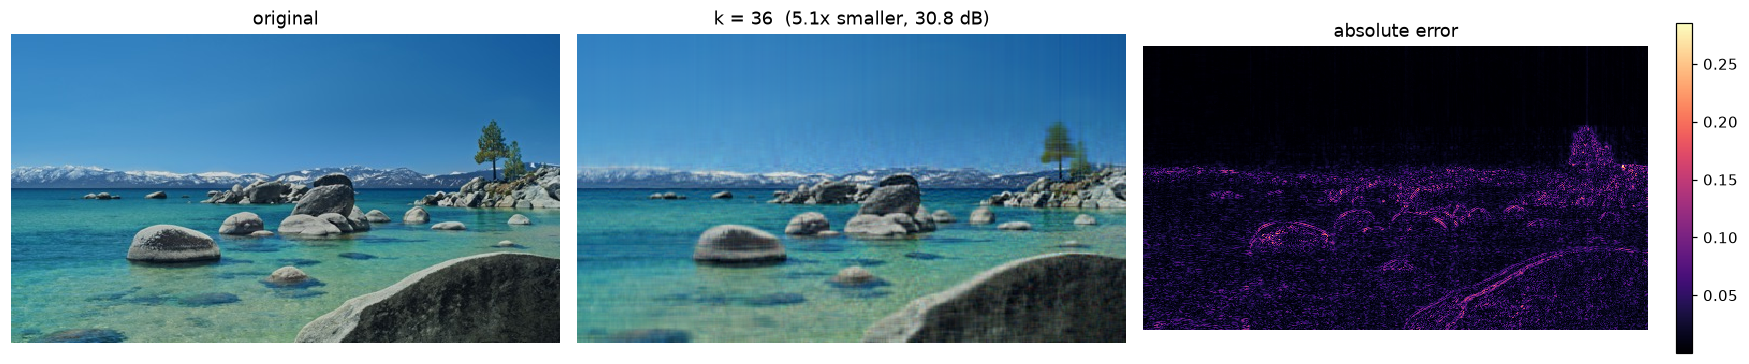

In [10]:
best = reconstruct(parts, k99, A.shape)
err = np.abs(A - best).mean(axis=2)

fig, ax = plt.subplots(1, 3, figsize=(16, 5 * m / n + 1))
ax[0].imshow(A if ch == 3 else A[:, :, 0], cmap=None if ch == 3 else "gray")
ax[0].set_title("original")
ax[1].imshow(best if ch == 3 else best[:, :, 0], cmap=None if ch == 3 else "gray")
ax[1].set_title(f"k = {k99}  ({full / (k99 * (m + n + 1) * ch):.1f}x smaller, "
                f"{psnr(A, best):.1f} dB)")
im = ax[2].imshow(err, cmap="magma")
ax[2].set_title("absolute error")
fig.colorbar(im, ax=ax[2], fraction=0.03)
for a_ in ax:
    a_.axis("off")
plt.tight_layout()
plt.show()

## 8. Write the compressed data out

Only the truncated factors go to disk, stored as `float16`. Everything needed to
rebuild the picture is in that one file.

In [11]:
def save_compressed(path, parts, k, shape):
    blobs = {"shape": np.array(shape)}
    for c, (u, s, vt) in enumerate(parts):
        blobs[f"u{c}"] = u[:, :k].astype(np.float16)
        blobs[f"s{c}"] = s[:k].astype(np.float32)
        blobs[f"vt{c}"] = vt[:k, :].astype(np.float16)
    np.savez_compressed(path, **blobs)
    return os.path.getsize(path)


def load_compressed(path):
    z = np.load(path)
    shape = tuple(z["shape"])
    out = np.empty(shape)
    for c in range(shape[2]):
        out[:, :, c] = (z[f"u{c}"].astype(np.float64) * z[f"s{c}"]) @ z[f"vt{c}"].astype(np.float64)
    return np.clip(out, 0.0, 1.0)


path = os.path.join(OUTDIR, f"compressed_k{k99}.npz")
size_kb = save_compressed(path, parts, k99, A.shape) / 1024
roundtrip = load_compressed(path)

print(f"{path}: {size_kb:.1f} KB")
print(f"round-trip PSNR: {psnr(A, roundtrip):.2f} dB  (float16 costs a little)")

Image.fromarray(np.round(roundtrip * 255).astype(np.uint8).squeeze()).save(
    os.path.join(OUTDIR, f"reconstructed_k{k99}.png"))

output_notebook/compressed_k36.npz: 158.9 KB
round-trip PSNR: 30.83 dB  (float16 costs a little)


## 9. One honest caveat

Those `.npz` files are raw numbers with no entropy coding, so on disk they usually
come out **larger** than the same image saved as PNG or JPEG. Truncated SVD
compresses the *rank* of the matrix, not the byte stream, and real codecs spend most
of their cleverness on the coding step that this notebook skips.

Read the `stored` and `ratio` columns for the real result. What the SVD genuinely
buys you is elsewhere: a low-rank representation you can compute with directly, and
a principled knob for trading detail against size. The same truncation is the engine
behind PCA, latent semantic analysis, and noise filtering.

**Things to try**

- Reload with `load_image(IMAGE_PATH, gray=True)`. One channel needs far fewer layers.
- Compare a photograph against a screenshot of text. Sharp glyph edges spread energy
  across the whole spectrum, so text compresses badly.
- Reconstruct from the *middle* of the spectrum, say layers 20 to 60, to see what
  each band of singular values contributes.